In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cmapss-jet-engine-simulated-data' dataset.
Path to dataset files: /kaggle/input/cmapss-jet-engine-simulated-data


In [ ]:
import os

os.listdir(path)

['RUL_FD002.txt',
 'test_FD003.txt',
 'Damage Propagation Modeling.pdf',
 'readme.txt',
 'train_FD003.txt',
 'test_FD004.txt',
 'train_FD004.txt',
 'test_FD002.txt',
 'train_FD001.txt',
 'train_FD002.txt',
 'RUL_FD001.txt',
 'RUL_FD004.txt',
 'RUL_FD003.txt',
 'test_FD001.txt']

In [ ]:
import pandas as pd

train_path = f"{path}/train_FD001.txt"
test_path = f"{path}/test_FD001.txt"
rul_path = f"{path}/RUL_FD001.txt"

columns = (
    ["engine_id","cycle"]
    + [f"setting{i}" for i in range(1,4)]
    + [f"s{i}" for i in range(1,22)]
)

train = pd.read_csv(train_path, sep=" ", header=None)
train = train.dropna(axis=1)
train.columns = columns

train.head()

,engine_id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train.shape

(20631, 26)

In [ ]:
train.engine_id.nunique()

100

In [ ]:
max_cycle = train.groupby("engine_id")["cycle"].max()

train = train.merge(max_cycle, on="engine_id", suffixes=("", "_max"))

train["RUL"] = train["cycle_max"] - train["cycle"]

train.drop("cycle_max", axis=1, inplace=True)

train.head()

,engine_id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [ ]:
train["RUL"] = train["RUL"].clip(upper=125)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# remove identifiers
corr_data = train.drop(columns=["engine_id","cycle"])

corr_matrix = corr_data.corr()

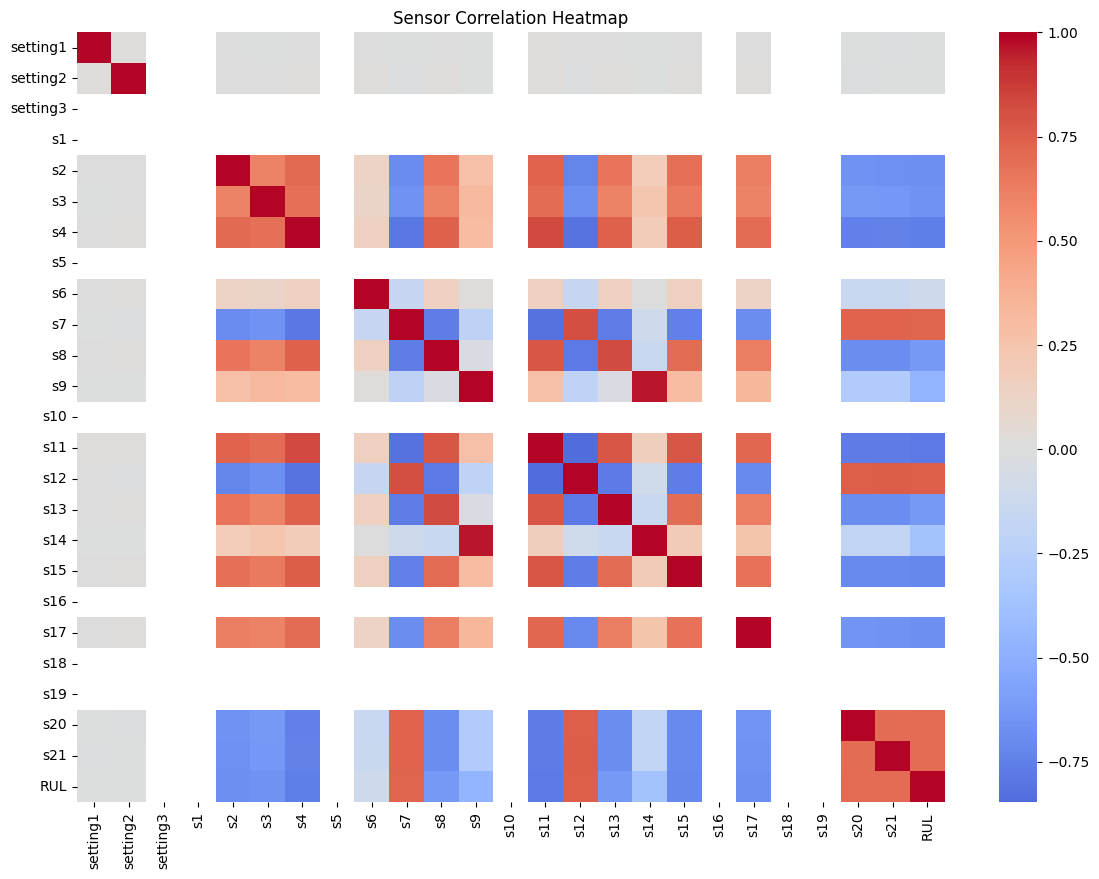

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Sensor Correlation Heatmap")
plt.show()

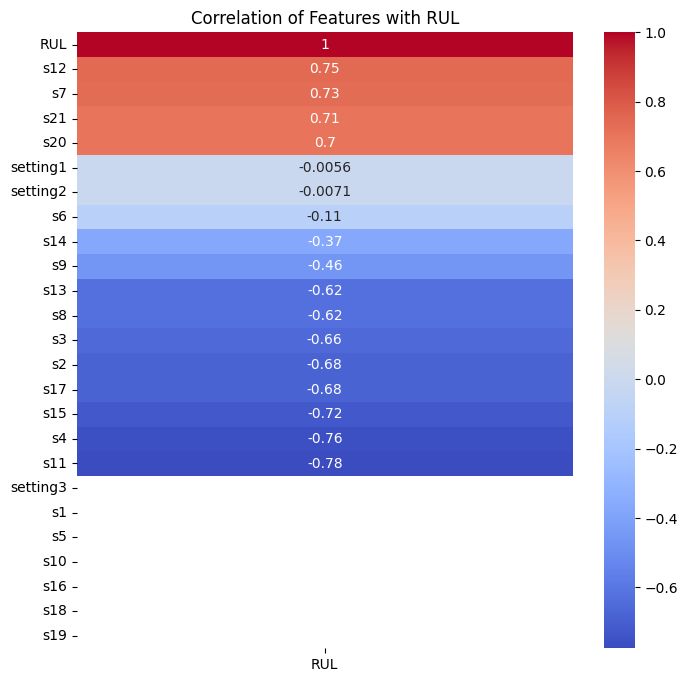

In [ ]:
rul_corr = corr_matrix["RUL"].sort_values(ascending=False)

plt.figure(figsize=(8,8))
sns.heatmap(rul_corr.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation of Features with RUL")
plt.show()

In [ ]:
drop_sensors = ["s1","s5","s6","s10","s16","s18","s19"]

train = train.drop(columns=drop_sensors)

In [ ]:
features = train.drop(["engine_id","cycle","RUL"], axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [ ]:
import pandas as pd

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

train_scaled = pd.concat(
    [train[["engine_id","cycle","RUL"]], scaled_df],
    axis=1
)

In [ ]:
train_scaled.head()

,engine_id,cycle,RUL,setting1,setting2,setting3,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,1,1,125,-0.315980,-1.372953,0.0,-1.721725,-0.134255,-0.925936,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427
1,1,2,125,0.872722,-1.031720,0.0,-1.061780,0.211528,-0.643726,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922
2,1,3,125,-1.961874,1.015677,0.0,-0.661813,-0.413166,-0.525953,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423
3,1,4,125,0.324090,-0.008022,0.0,-0.661813,-1.261314,-0.784831,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792
4,1,5,125,-0.864611,-0.690488,0.0,-0.621816,-1.251528,-0.301518,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552


In [ ]:
train_scaled["RUL"].value_counts()

,count
RUL,
125,8131
124,100
123,100
122,100
121,100
...,...
4,100
3,100
2,100


In [ ]:
import numpy as np

window = 30

X = []
y = []

for engine in train_scaled.engine_id.unique():

    engine_df = train_scaled[train_scaled.engine_id == engine]

    data = engine_df.drop(["engine_id","cycle","RUL"], axis=1).values
    rul = engine_df["RUL"].values

    for i in range(len(data) - window):

        X.append(data[i:i+window])
        y.append(rul[i+window])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17631, 30, 17)
y shape: (17631,)


In [ ]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

In [ ]:
import torch.nn as nn

class CNNLSTM(nn.Module):

    def __init__(self, input_features):

        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=input_features,
            out_channels=64,
            kernel_size=3
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        # (batch, time, features) → (batch, features, time)
        x = x.permute(0,2,1)

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        # (batch, features, time) → (batch, time, features)
        x = x.permute(0,2,1)

        x,_ = self.lstm(x)

        x = x[:,-1,:]

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [ ]:
model = CNNLSTM(X.shape[2])

In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 25
batch_size = 128

for epoch in range(epochs):

    model.train()

    perm = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), batch_size):

        idx = perm[i:i+batch_size]

        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()

        outputs = model(batch_x).squeeze()

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

Epoch 1 Loss: 7102.9888
Epoch 2 Loss: 5614.1602
Epoch 3 Loss: 5513.6030
Epoch 4 Loss: 3784.8684
Epoch 5 Loss: 4252.8374
Epoch 6 Loss: 3538.6309
Epoch 7 Loss: 2831.1189
Epoch 8 Loss: 2503.7576
Epoch 9 Loss: 2266.9373
Epoch 10 Loss: 2412.6536
Epoch 11 Loss: 2389.2617
Epoch 12 Loss: 1717.0337
Epoch 13 Loss: 2214.5168
Epoch 14 Loss: 2001.3221
Epoch 15 Loss: 1901.7235
Epoch 16 Loss: 1139.8267
Epoch 17 Loss: 663.6171
Epoch 18 Loss: 918.4605
Epoch 19 Loss: 609.8930
Epoch 20 Loss: 445.6537
Epoch 21 Loss: 369.2480
Epoch 22 Loss: 401.7538
Epoch 23 Loss: 200.7301
Epoch 24 Loss: 302.1317
Epoch 25 Loss: 229.2048


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

model.eval()

with torch.no_grad():

    preds = model(X_val).squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_val.numpy(), preds))

print("Validation RMSE:", rmse)

Validation RMSE: 14.370762474096983


In [ ]:
def preprocess_train(df, window=30):

    # remove weak sensors
    drop_sensors = ["s1","s5","s6","s10","s16","s18","s19"]
    df = df.drop(columns=drop_sensors)

    # compute RUL
    max_cycle = df.groupby("engine_id")["cycle"].max()

    df = df.merge(max_cycle, on="engine_id", suffixes=("", "_max"))

    df["RUL"] = df["cycle_max"] - df["cycle"]

    df.drop("cycle_max", axis=1, inplace=True)

    # clip RUL
    df["RUL"] = df["RUL"].clip(upper=125)

    return df

In [ ]:
from sklearn.preprocessing import StandardScaler

features = train.drop(["engine_id","cycle","RUL"], axis=1)

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled, columns=features.columns)

train_scaled = pd.concat(
    [train[["engine_id","cycle","RUL"]], scaled_df],
    axis=1
)

In [ ]:
import numpy as np

def create_train_windows(df, window=30):

    X = []
    y = []

    for engine in df.engine_id.unique():

        engine_df = df[df.engine_id == engine]

        data = engine_df.drop(["engine_id","cycle","RUL"], axis=1).values
        rul = engine_df["RUL"].values

        for i in range(len(data) - window):

            X.append(data[i:i+window])
            y.append(rul[i+window])

    return np.array(X), np.array(y)

In [ ]:
test = pd.read_csv(test_path, sep=" ", header=None)
test = test.dropna(axis=1)
test.columns = columns

rul = pd.read_csv(rul_path, header=None)

In [ ]:
drop_sensors = ["s1","s5","s6","s10","s16","s18","s19"]

test = test.drop(columns=drop_sensors)

In [ ]:
test_features = test.drop(["engine_id","cycle"], axis=1)

test_scaled = scaler.transform(test_features)

test_scaled = pd.DataFrame(test_scaled, columns=test_features.columns)

test_scaled = pd.concat(
    [test[["engine_id","cycle"]], test_scaled],
    axis=1
)

In [ ]:
def create_test_windows(df, window=30):

    X_test = []

    for engine in df.engine_id.unique():

        engine_df = df[df.engine_id == engine]

        data = engine_df.drop(["engine_id","cycle"], axis=1).values

        X_test.append(data[-window:])

    return np.array(X_test)

In [ ]:
X_test = create_test_windows(test_scaled)

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()

with torch.no_grad():

    preds = model(X_test_tensor).squeeze().numpy()

In [ ]:
true_rul = rul[0].values

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(true_rul, preds))

print("Test RMSE:", rmse)

Test RMSE: 18.425968818607526


In [ ]:
def nasa_score(y_true, y_pred):

    score = 0

    for t, p in zip(y_true, y_pred):

        d = p - t

        if d < 0:
            score += np.exp(-d/13) - 1
        else:
            score += np.exp(d/10) - 1

    return score

In [ ]:
score = nasa_score(true_rul, preds)

print("NASA Score:", score)

NASA Score: 484.4733585546546


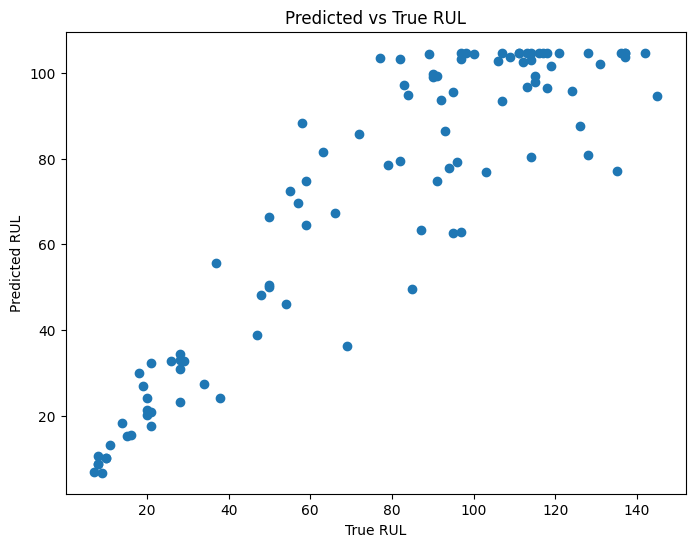

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(true_rul, preds)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")

plt.title("Predicted vs True RUL")

plt.show()

In [ ]:
epochs = 60

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [ ]:
torch.save(model.state_dict(), "cmapss_cnn_lstm_fd001.pth")

In [ ]:
best_val_loss = float("inf")
patience = 5
counter = 0
increase_threshold = 1.10   # 10% increase

In [ ]:
import torch
from sklearn.metrics import mean_squared_error
import numpy as np

epochs = 100
batch_size = 128

best_val_loss = float("inf")
patience = 5
counter = 0

increase_threshold = 1.25  # 25% increase rule

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()

    perm = torch.randperm(X_train.size(0))
    epoch_loss = 0

    for i in range(0, X_train.size(0), batch_size):

        idx = perm[i:i+batch_size]

        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()

        outputs = model(batch_x).squeeze()

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / (X_train.size(0) / batch_size)

    train_losses.append(train_loss)

    # --------------------
    # Validation
    # --------------------

    model.eval()

    with torch.no_grad():

        preds = model(X_val).squeeze()

        val_loss = criterion(preds, y_val)

    val_loss = val_loss.item()

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    # --------------------
    # Early Stopping Logic
    # --------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    elif val_loss > best_val_loss * increase_threshold:

        print("Stopping: Validation loss increased by >25% (overfitting)")
        break

    else:

        counter += 1

        if counter >= patience:
            print("Stopping: No improvement for 5 epochs")
            break

Epoch 1
Train Loss: 228.4534
Val Loss: 165.5381
Epoch 2
Train Loss: 198.7767
Val Loss: 153.4522
Epoch 3
Train Loss: 180.2374
Val Loss: 127.8312
Epoch 4
Train Loss: 164.0435
Val Loss: 111.2671
Epoch 5
Train Loss: 152.6121
Val Loss: 98.2276
Epoch 6
Train Loss: 139.3899
Val Loss: 85.9968
Epoch 7
Train Loss: 129.0708
Val Loss: 83.0918
Epoch 8
Train Loss: 126.2935
Val Loss: 67.8438
Epoch 9
Train Loss: 114.8727
Val Loss: 69.3352
Epoch 10
Train Loss: 108.9384
Val Loss: 60.2506
Epoch 11
Train Loss: 106.5930
Val Loss: 56.6242
Epoch 12
Train Loss: 107.2167
Val Loss: 50.8665
Epoch 13
Train Loss: 103.3011
Val Loss: 50.2298
Epoch 14
Train Loss: 97.9510
Val Loss: 48.2451
Epoch 15
Train Loss: 96.2839
Val Loss: 54.7021
Epoch 16
Train Loss: 95.3149
Val Loss: 47.5484
Epoch 17
Train Loss: 92.9144
Val Loss: 43.3708
Epoch 18
Train Loss: 90.9288
Val Loss: 52.4114
Epoch 19
Train Loss: 88.0773
Val Loss: 49.2305
Epoch 20
Train Loss: 87.0068
Val Loss: 45.9331
Epoch 21
Train Loss: 87.9930
Val Loss: 44.9779
Epoch

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [ ]:
model.eval()

with torch.no_grad():

    preds = model(X_val).squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_val.numpy(), preds))

print("Validation RMSE:", rmse)

Validation RMSE: 4.772074153519052


In [ ]:
engines = train_scaled.engine_id.unique()

train_engines = engines[:80]
val_engines = engines[80:]

In [ ]:
train_df = train_scaled[train_scaled.engine_id.isin(train_engines)]
val_df = train_scaled[train_scaled.engine_id.isin(val_engines)]

In [ ]:
X_train, y_train = create_train_windows(train_df)
X_val, y_val = create_train_windows(val_df)

In [ ]:
test = pd.read_csv(test_path, sep=" ", header=None)

test = test.dropna(axis=1)

test.columns = columns

In [ ]:
rul = pd.read_csv(rul_path, header=None)
true_rul = rul[0].values

In [ ]:
drop_sensors = ["s1","s5","s6","s10","s16","s18","s19"]

test = test.drop(columns=drop_sensors)

In [ ]:
test_features = test.drop(["engine_id","cycle"], axis=1)

test_scaled = scaler.transform(test_features)

test_scaled = pd.DataFrame(test_scaled, columns=test_features.columns)

test_scaled = pd.concat(
    [test[["engine_id","cycle"]], test_scaled],
    axis=1
)

In [ ]:
def create_test_windows(df, window=30):

    X_test = []

    for engine in df.engine_id.unique():

        engine_df = df[df.engine_id == engine]

        data = engine_df.drop(["engine_id","cycle"], axis=1).values

        X_test.append(data[-window:])

    return np.array(X_test)

In [ ]:
X_test = create_test_windows(test_scaled)

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [ ]:
model.eval()

with torch.no_grad():

    preds = model(X_test_tensor).squeeze().numpy()

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(true_rul, preds))

print("Test RMSE:", rmse)

Test RMSE: 17.152253454983235


In [ ]:
def nasa_score(y_true, y_pred):

    score = 0

    for t, p in zip(y_true, y_pred):

        d = p - t

        if d < 0:
            score += np.exp(-d/13) - 1
        else:
            score += np.exp(d/10) - 1

    return score

In [ ]:
score = nasa_score(true_rul, preds)

print("NASA Score:", score)

NASA Score: 507.41922620515834


In [ ]:
torch.save(model.state_dict(), "cnn_lstm_cmapss_fd001.pth")

In [ ]:
model = CNNLSTM(input_features=17)
model.load_state_dict(torch.load("cnn_lstm_cmapss_fd001.pth"))
model.eval()

CNNLSTM(
  (conv1): Conv1d(17, 64, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
import joblib

joblib.dump(scaler, "cmapss_scaler.pkl")

['cmapss_scaler.pkl']

In [ ]:
scaler = joblib.load("cmapss_scaler.pkl")

In [ ]:
import json

config = {
    "window_size": 30,
    "dropped_sensors": ["s1","s5","s6","s10","s16","s18","s19"],
    "features": 17
}

with open("model_config.json","w") as f:
    json.dump(config,f)

In [ ]:
def predict_rul(engine_df):

    engine_df = engine_df.drop(columns=["s1","s5","s6","s10","s16","s18","s19"])

    features = engine_df.drop(["engine_id","cycle"], axis=1)

    features = scaler.transform(features)

    window = features[-30:]

    X = torch.tensor(window).unsqueeze(0).float()

    model.eval()

    with torch.no_grad():
        pred = model(X).item()

    return pred

In [ ]:
torch.save(model.state_dict(), "cnn_lstm_fd001.pth")

import joblib
joblib.dump(scaler, "scaler_fd001.pkl")

AttributeError: 'XGBRegressor' object has no attribute 'state_dict'

In [ ]:
from google.colab import files

files.download("cnn_lstm_fd001.pth")
files.download("scaler_fd001.pkl")

In [ ]:
!zip model_files.zip cnn_lstm_fd001.pth scaler_fd001.pkl

In [ ]:
X_flat = X.reshape(X.shape[0], -1)

print(X_flat.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

preds = xgb_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))

print("XGBoost RMSE:", rmse)

In [ ]:
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [ ]:
preds_test = xgb_model.predict(X_test_flat)

In [ ]:
rmse_test = np.sqrt(mean_squared_error(true_rul, preds_test))

print("Test RMSE:", rmse_test)

In [ ]:
def nasa_score(y_true, y_pred):

    score = 0

    for t, p in zip(y_true, y_pred):

        d = p - t

        if d < 0:
            score += np.exp(-d/13) - 1
        else:
            score += np.exp(d/10) - 1

    return score

score = nasa_score(true_rul, preds_test)

print("NASA Score:", score)

In [ ]:
import joblib

joblib.dump(xgb_model, "xgboost_fd001.pkl")

In [ ]:
from google.colab import files

files.download("xgboost_fd001.pkl")

In [ ]:
joblib.dump(scaler, "scaler_fd001.pkl")

files.download("scaler_fd001.pkl")

In [ ]:
import json

config = {
    "window_size": 30,
    "dropped_sensors": ["s1","s5","s6","s10","s16","s18","s19"]
}

with open("config.json", "w") as f:
    json.dump(config, f)

files.download("config.json")

In [ ]:
xgb_model = joblib.load("xgboost_fd001.pkl")
scaler = joblib.load("scaler_fd001.pkl")

In [ ]:
pip install optuna

In [ ]:
import optuna
import lightgbm as lgb

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    model = lgb.LGBMRegressor(**params)
    # ... fit and return val RMSE

In [ ]:
class NASALoss(nn.Module):
    def forward(self, pred, target):
        diff = pred - target  # positive = overestimate (late prediction)
        score = torch.where(
            diff < 0,
            torch.exp(-diff / 13) - 1,   # early prediction
            torch.exp(diff / 10) - 1     # late prediction (penalized more)
        )
        return score.mean()

In [ ]:
class CNNLSTM(nn.Module):

    def __init__(self, input_features):

        super().__init__()

        self.conv1 = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)

        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128,1)

    def forward(self,x):

        x = x.permute(0,2,1)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        x = x.permute(0,2,1)

        x,_ = self.lstm(x)

        x = x[:,-1,:]

        x = self.dropout(x)

        return self.fc(x)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

epochs = 100
batch_size = 128

best_val_loss = float("inf")
patience = 5
counter = 0
increase_threshold = 1.25  # your 25% rule

train_losses = []
val_losses = []
val_rmses = []

for epoch in range(epochs):

    # -------------------
    # TRAINING
    # -------------------
    model.train()
    perm = torch.randperm(X_train.size(0))

    epoch_loss = 0

    for i in range(0, X_train.size(0), batch_size):

        idx = perm[i:i+batch_size]

        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()

        outputs = model(batch_x).squeeze()

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / (X_train.size(0) / batch_size)
    train_losses.append(train_loss)

    # -------------------
    # VALIDATION
    # -------------------
    model.eval()

    with torch.no_grad():
        preds = model(X_val).squeeze()

        val_loss = criterion(preds, y_val).item()

    val_losses.append(val_loss)

    # RMSE
    preds_np = preds.numpy()
    y_np = y_val.numpy()

    rmse = np.sqrt(mean_squared_error(y_np, preds_np))
    val_rmses.append(rmse)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val RMSE: {rmse:.4f}")

    # -------------------
    # EARLY STOPPING
    # -------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_cnn_lstm.pth")

    elif val_loss > best_val_loss * increase_threshold:

        print("Stopping: Loss increased >25% (overfitting)")
        break

    else:

        counter += 1

        if counter >= patience:
            print("Stopping: No improvement (patience reached)")
            break

In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)

# 🔥 Use Huber loss (better than MSE here)
criterion = torch.nn.SmoothL1Loss()

epochs = 100
batch_size = 128

best_val_loss = float("inf")
patience = 5
counter = 0
increase_threshold = 1.25

train_losses = []
val_losses = []
val_rmses = []

for epoch in range(epochs):

    # -------------------
    # TRAINING
    # -------------------
    model.train()
    perm = torch.randperm(X_train.size(0))

    epoch_loss = 0
    num_batches = 0

    for i in range(0, X_train.size(0), batch_size):

        idx = perm[i:i+batch_size]

        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()

        outputs = model(batch_x).squeeze()

        loss = criterion(outputs, batch_y)

        loss.backward()

        # 🔥 Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    train_loss = epoch_loss / num_batches
    train_losses.append(train_loss)

    # -------------------
    # VALIDATION
    # -------------------
    model.eval()

    with torch.no_grad():
        preds = model(X_val).squeeze()

        val_loss = criterion(preds, y_val).item()

    val_losses.append(val_loss)

    # RMSE
    preds_np = preds.detach().cpu().numpy()
    y_np = y_val.detach().cpu().numpy()

    rmse = np.sqrt(mean_squared_error(y_np, preds_np))
    val_rmses.append(rmse)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val RMSE: {rmse:.4f}")

    # 🔥 Debug: check predictions
    print("Pred sample:", preds_np[:5])
    print("True sample:", y_np[:5])

    # -------------------
    # EARLY STOPPING
    # -------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_cnn_lstm.pth")

    elif val_loss > best_val_loss * increase_threshold:

        print("Stopping: Loss increased >25% (overfitting)")
        break

    else:

        counter += 1

        if counter >= patience:
            print("Stopping: No improvement (patience reached)")
            break

In [ ]:
engines = train_scaled.engine_id.unique()

train_engines = engines[:80]
val_engines = engines[80:]

In [ ]:
train_df = train_scaled[train_scaled.engine_id.isin(train_engines)]
val_df = train_scaled[train_scaled.engine_id.isin(val_engines)]

In [ ]:
X_train, y_train = create_train_windows(train_df)
X_val, y_val = create_train_windows(val_df)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

In [ ]:
print("X_train shape:", X_train.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [ ]:
print(X_train.shape)

In [ ]:
train_path = f"{path}/train_FD002.txt"
test_path = f"{path}/test_FD002.txt"
rul_path = f"{path}/RUL_FD002.txt"

In [ ]:
scaler = StandardScaler()

In [ ]:
window = 30

In [ ]:
X, y = create_train_windows(train_scaled)

In [ ]:
X_flat = X.reshape(X.shape[0], -1)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=800,   # ↑ increase for FD002
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

xgb_model.fit(X_flat, y)

In [ ]:
X_test = create_test_windows(test_scaled)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [ ]:
preds = xgb_model.predict(X_test_flat)

In [ ]:
rmse = np.sqrt(mean_squared_error(true_rul, preds))
print("RMSE:", rmse)

In [ ]:
score = nasa_score(true_rul, preds)
print("NASA Score:", score)

In [ ]:
import joblib

joblib.dump(xgb_model, "xgboost_fd002.pkl")

In [ ]:
joblib.dump(scaler, "scaler_fd002.pkl")

In [ ]:
from google.colab import files

files.download("xgboost_fd002.pkl")
files.download("scaler_fd002.pkl")

In [ ]:
preds = xgb_model.predict(X_test_flat)

print("RMSE:", np.sqrt(mean_squared_error(true_rul, preds)))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_flat, y)

In [ ]:
preds_rf = rf_model.predict(X_test_flat)

In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=0
)

cat_model.fit(X_flat, y)

In [ ]:
preds_cat = cat_model.predict(X_test_flat)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(true_rul, preds_rf))


print("RF RMSE:", rmse_rf)


In [ ]:
score_rf = nasa_score(true_rul, preds_rf)


print("RF NASA:", score_rf)


In [ ]:
from sklearn.metrics import r2_score

r2_score = np.sqrt(r2_score(true_rul,preds))
r2_score

In [ ]:
train_path = f"{path}/train_FD003.txt"
test_path = f"{path}/test_FD003.txt"
rul_path = f"{path}/RUL_FD003.txt"

In [ ]:
import pandas as pd

train = pd.read_csv(train_path, sep=" ", header=None).dropna(axis=1)
test = pd.read_csv(test_path, sep=" ", header=None).dropna(axis=1)
rul = pd.read_csv(rul_path, header=None)

true_rul = rul[0].values

In [ ]:
cols = ["engine_id", "cycle"] + \
       [f"setting{i}" for i in range(1,4)] + \
       [f"s{i}" for i in range(1,22)]

train.columns = cols
test.columns = cols

In [ ]:
max_cycle = train.groupby("engine_id")["cycle"].max()

train["RUL"] = train.apply(
    lambda row: max_cycle[row["engine_id"]] - row["cycle"],
    axis=1
)

# clip
train["RUL"] = train["RUL"].clip(upper=125)

In [ ]:
drop_sensors = ["s1","s5","s6","s10","s16","s18","s19"]

train = train.drop(columns=drop_sensors)
test = test.drop(columns=drop_sensors)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_features = train.drop(["engine_id","cycle","RUL"], axis=1)

train_scaled = scaler.fit_transform(train_features)

train_scaled = pd.DataFrame(train_scaled, columns=train_features.columns)

train_scaled = pd.concat(
    [train[["engine_id","cycle","RUL"]], train_scaled],
    axis=1
)

In [ ]:
test_features = test.drop(["engine_id","cycle"], axis=1)

test_scaled = scaler.transform(test_features)

test_scaled = pd.DataFrame(test_scaled, columns=test_features.columns)

test_scaled = pd.concat(
    [test[["engine_id","cycle"]], test_scaled],
    axis=1
)

In [ ]:
def create_train_windows(df, window=30):

    X, y = [], []

    for engine in df.engine_id.unique():

        engine_df = df[df.engine_id == engine]

        data = engine_df.drop(["engine_id","cycle","RUL"], axis=1).values
        rul = engine_df["RUL"].values

        for i in range(len(data) - window):
            X.append(data[i:i+window])
            y.append(rul[i+window])

    return np.array(X), np.array(y)

In [ ]:
X, y = create_train_windows(train_scaled)

In [ ]:
X_flat = X.reshape(X.shape[0], -1)

In [ ]:
def create_test_windows(df, window=30):

    X_test = []

    for engine in df.engine_id.unique():

        engine_df = df[df.engine_id == engine]

        data = engine_df.drop(["engine_id","cycle"], axis=1).values

        X_test.append(data[-window:])

    return np.array(X_test)

In [ ]:
X_test = create_test_windows(test_scaled)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

xgb_model.fit(X_flat, y)

In [ ]:
preds = xgb_model.predict(X_test_flat)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(true_rul, preds))
print("RMSE:", rmse)

In [ ]:
def nasa_score(y_true, y_pred):

    score = 0

    for t, p in zip(y_true, y_pred):

        d = p - t

        if d < 0:
            score += np.exp(-d/13) - 1
        else:
            score += np.exp(d/10) - 1

    return score


rmse = np.sqrt(mean_squared_error(true_rul, preds))
print("RMSE:", rmse)
score = nasa_score(true_rul, preds)
print("NASA Score:", score)

In [ ]:
pip install catboost

In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=0
)

cat_model.fit(X_flat, y)

preds_cat = cat_model.predict(X_test_flat)

In [ ]:
score = nasa_score(true_rul, preds_cat)
print("NASA Score:", score)

In [ ]:
rmse = np.sqrt(mean_squared_error(true_rul, preds_cat))
print("RMSE:", rmse)

In [ ]:
X_stack_test = np.vstack((preds, preds_cat)).T

In [ ]:
final_preds = 0.7 * preds + 0.3 * preds_cat

In [ ]:
rmse = np.sqrt(mean_squared_error(true_rul, final_preds))
score = nasa_score(true_rul, final_preds)

print("Hybrid RMSE:", rmse)
print("Hybrid NASA:", score)

In [ ]:
XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0.1
)

In [ ]:
xgb_model.fit(X_flat, y)


In [ ]:


rmse = np.sqrt(mean_squared_error(true_rul, preds))
print("RMSE:", rmse)
score = nasa_score(true_rul, preds)
print("NASA Score:", score)

In [ ]:
def extract_features(X):

    # X shape: (samples, window, features)

    last = X[:, -1, :]                 # last timestep
    mean = X.mean(axis=1)              # average
    std = X.std(axis=1)                # variation
    trend = X[:, -1, :] - X[:, 0, :]   # degradation trend

    # original flattened
    flat = X.reshape(X.shape[0], -1)

    # combine everything
    return np.concatenate([flat, last, mean, std, trend], axis=1)

In [ ]:
X_enhanced = extract_features(X)
X_test_enhanced = extract_features(X_test)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1200,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0.1,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(X_enhanced, y)

In [ ]:


preds = xgb_model.predict(X_test_enhanced)

In [ ]:
rmse = np.sqrt(mean_squared_error(true_rul, preds))
score = nasa_score(true_rul, preds)

print("RMSE:", rmse)
print("NASA Score:", score)